In [ ]:
# # [Cell 1] 설치 & 환경 점검
# # - 이미 설치되어 있다면 이 셀은 건너뛰어도 됩니다.

# import sys, subprocess, importlib

# def _pip_install(pkg):
#     print(f"Installing: {pkg}")
#     subprocess.check_call([sys.executable, "-m", "pip", "install", "-U"] + pkg.split())

# # 필수 패키지 점검
# try:
#     import stable_baselines3 as sb3  # noqa
# except Exception:
#     _pip_install("stable-baselines3[extra]")

# # gym-jsbsim과 jsbsim은 환경에 따라 설치가 필요할 수 있음
# mods = {"gym_jsbsim": "gym-jsbsim", "jsbsim": "JSBSim"}
# for m, p in mods.items():
#     try:
#         importlib.import_module(m)
#     except Exception:
#         _pip_install(p)

# # gym은 0.21~0.26 계열을 주로 사용
# try:
#     import gym  # noqa
# except Exception:
#     _pip_install("gym==0.26.2")

# print("✅ 설치(또는 기존 설치 확인) 완료")


In [1]:
# [Cell 2] 공통 import, 버전 출력, 시드 고정
import os, time, json, math, random, warnings
from pathlib import Path

import numpy as np
import gym
import gym_jsbsim  # 환경 등록용 (import만 해도 env id가 등록됨)

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, SubprocVecEnv, VecMonitor, VecNormalize, VecFrameStack
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import (
    EvalCallback, CheckpointCallback, StopTrainingOnNoModelImprovement, CallbackList
)
from stable_baselines3.common.logger import configure
from stable_baselines3.common.evaluation import evaluate_policy

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

print("Versions")
import stable_baselines3, gym_jsbsim, jsbsim
print("  stable_baselines3:", stable_baselines3.__version__)
print("  gym:", gym.__version__)
print("  gym_jsbsim:", getattr(gym_jsbsim, "__version__", "unknown"))
print("  jsbsim:", getattr(jsbsim, "__version__", "unknown"))

# 시드 고정 함수
def set_global_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    except Exception:
        pass

SEED = 42
set_global_seed(SEED)

# 로그/모델 저장 경로
curtime = time.strftime("%Y%m%d_%H%M%S")
ROOT = Path("./logs/ppo_jsbsim") / curtime
TB_DIR = ROOT / "tb"
MODEL_DIR = ROOT / "models"
EVAL_DIR = ROOT / "eval"

for p in [ROOT, TB_DIR, MODEL_DIR, EVAL_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Log root:", str(ROOT))


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Versions
  stable_baselines3: 2.7.0
  gym: 0.26.2
  gym_jsbsim: unknown
  jsbsim: 1.1.1
Log root: logs/ppo_jsbsim/20250810_163322


In [2]:
import numpy as np
if not hasattr(np, 'bool8'):
    np.bool8 = np.bool_


In [3]:
# [Cell 3] 보강 래퍼들: 행동 L2 패널티(일반적), 도메인 랜덤화(옵션)
# - 행동 크기가 과도하게 커지는 것을 억제해 학습을 안정화합니다.
# - 도메인 랜덤화는 JSBSim 환경에서 바람/기압 등을 세팅할 수 있을 때만 동작하며, 불가 시 무시합니다.

class ActionL2PenaltyWrapper(gym.Wrapper):
    """
    보상에 -lambda * ||action||^2 패널티를 추가.
    """
    def __init__(self, env, lam: float = 0.001):
        super().__init__(env)
        self.lam = lam
        self._last_action = None

    def step(self, action):
        self._last_action = action
        obs, reward, done, info = self.env.step(action)
        try:
            a = np.asarray(action, dtype=np.float32)
            reward = float(reward) - float(self.lam) * float(np.sum(a*a))
        except Exception:
            pass
        return obs, reward, done, info


class DomainRandomizationWrapper(gym.Wrapper):
    """
    reset 시 바람/난류/기압 등 일부 초기 조건을 무작위화.
    환경이 관련 세터를 제공하지 않으면 조용히 패스.
    """
    def __init__(self, env,
                 wind_speed_range=(0.0, 12.0),
                 wind_dir_range=(0.0, 360.0),
                 turbulence_sigma_range=(0.0, 2.0)):
        super().__init__(env)
        self.wind_speed_range = wind_speed_range
        self.wind_dir_range = wind_dir_range
        self.turbulence_sigma_range = turbulence_sigma_range

    def reset(self, **kwargs):
        # 가능한 세터들을 best-effort로 호출
        try:
            # 대표적인 예시 메서드/프로퍼티 이름들 (환경 구현에 따라 없을 수 있음)
            un = self.env.unwrapped
            spd = np.random.uniform(*self.wind_speed_range)
            direc = np.random.uniform(*self.wind_dir_range)
            sig = np.random.uniform(*self.turbulence_sigma_range)

            for name in [
                "set_initial_wind",      # (speed, direction)
                "set_wind",              # (speed, direction)
                "configure_wind"         # (speed, direction, sigma)
            ]:
                if hasattr(un, name):
                    fn = getattr(un, name)
                    try:
                        fn(spd, direc) if fn.__code__.co_argcount <= 3 else fn(spd, direc, sig)
                        break
                    except Exception:
                        continue

            # JSBSim 속성 직접 접근 방식(예: property tree)이 있는 경우
            # 속성 이름은 환경 구현에 따라 상이하므로 try/except
            for setter in [
                ("set_property_value", "atmosphere/wind-north-fps"),
                ("set_property_value", "atmosphere/wind-east-fps")
            ]:
                if hasattr(un, setter[0]):
                    spd_fps = spd * 3.28084
                    # 북/동 성분으로 분해
                    north = spd_fps * math.cos(math.radians(direc))
                    east = spd_fps * math.sin(math.radians(direc))
                    try:
                        getattr(un, setter[0])("atmosphere/wind-north-fps", north)
                        getattr(un, setter[0])("atmosphere/wind-east-fps",  east)
                        break
                    except Exception:
                        continue
        except Exception:
            pass

        return self.env.reset(**kwargs)


In [4]:
# [Cell 4] 환경 생성 함수 정의 (DummyVecEnv 패턴 고정)
# - 반드시 DummyVecEnv([make_env]) 형태를 사용
# - Monitor는 VecMonitor로만 기록, 개별 env 안에서는 Monitor를 쓰지 않음
# - 관측/보상 정규화(VecNormalize) 적용, 평가env는 학습 통계 공유

ENV_ID = "JSBSim-TurnHeadingControlTask-Cessna172P-Shaping.STANDARD-NoFG-v0"

N_ENVS = 1          # 반드시 DummyVecEnv 패턴을 쓰기 위해 1로 고정(필요 시 2 이상으로 늘려도 동일 패턴 유지)
STACK_FRAMES = 1    # 필요 시 4 등으로
USE_DOMAIN_RANDOM = True
ACTION_L2_LAMBDA = 0.001

def make_env():
    env = gym.make(ENV_ID)
    env.seed(SEED)
    # 행동 크기 패널티
    env = ActionL2PenaltyWrapper(env, lam=ACTION_L2_LAMBDA)
    # 도메인 랜덤화(가능한 경우에만 적용)
    if USE_DOMAIN_RANDOM:
        env = DomainRandomizationWrapper(env)
    return env

# ── 학습용 환경: DummyVecEnv → VecMonitor → VecNormalize → (옵션) VecFrameStack
train_env = DummyVecEnv([make_env for _ in range(N_ENVS)])
train_env = VecMonitor(train_env, filename=str(ROOT / "vecmonitor.csv"))
train_env = VecNormalize(train_env, norm_obs=True, norm_reward=True, clip_obs=10.0, clip_reward=10.0)
if STACK_FRAMES > 1:
    train_env = VecFrameStack(train_env, n_stack=STACK_FRAMES)

# ── 평가용 환경: 동일 구성 + VecNormalize 통계 공유, 보상 정규화 비활성
def make_eval_env():
    env = gym.make(ENV_ID)
    env.seed(SEED + 10_000)
    env = ActionL2PenaltyWrapper(env, lam=ACTION_L2_LAMBDA)
    if USE_DOMAIN_RANDOM:
        env = DomainRandomizationWrapper(env)
    return env

eval_env = DummyVecEnv([make_eval_env])
eval_env = VecMonitor(eval_env, filename=str(EVAL_DIR / "vecmonitor.csv"))
eval_env = VecNormalize(eval_env, norm_obs=True, norm_reward=False, clip_obs=10.0, clip_reward=10.0)

# 학습 중에도 관측 정규화 통계를 공유하도록 설정
# (최종적으로는 학습 종료 후 vecnormalize.pkl을 로드해주는 절차를 별도 평가 셀에서 수행)
eval_env.obs_rms = train_env.obs_rms
# 보상은 평가 시 정규화하지 않으므로 ret_rms 공유는 생략


In [5]:
# [Cell 5] 하이퍼파라미터 & 모델 정의, 콜백(평가/체크포인트/얼리스탑) 설정 - 안정화 튜닝 버전

import torch.nn as nn
from stable_baselines3.common.callbacks import (
    EvalCallback, CheckpointCallback, StopTrainingOnNoModelImprovement, CallbackList
)
from stable_baselines3.common.logger import configure
from stable_baselines3 import PPO

def linear_lr_schedule(initial_lr: float, final_lr: float = 5e-5):
    """선형 감소 스케줄: t=0 -> initial_lr, t=1 -> final_lr."""
    def func(progress_remaining: float):
        # progress_remaining: 1 -> 0
        return final_lr + (initial_lr - final_lr) * progress_remaining
    return func

policy_kwargs = dict(
    net_arch=dict(pi=[256, 256], vf=[256, 256]),
    activation_fn=nn.Tanh,
    ortho_init=False
)

model = PPO(
    policy="MlpPolicy",
    env=train_env,
    # ---- 안정화 핵심 튜닝 ----
    n_steps=4096,            # 수집 스텝 확대(분산↓)
    batch_size=128,          # 배치 확장(스텝 대비 1/32~1/64 권장)
    n_epochs=5,              # 에폭 축소(과적합/진동 억제)
    clip_range=0.1,          # 정책 클립 축소(보수적 업데이트)
    clip_range_vf=0.2,       # 값함수 클리핑 활성화
    target_kl=0.02,          # KL 목표(과도 업데이트 시 자동 억제)
    learning_rate=linear_lr_schedule(2e-4, 5e-5),  # 더 낮고 완만한 스케줄
    gamma=0.995,
    gae_lambda=0.95,
    ent_coef=0.005,          # 탐색 유지(필요시 0.01로↑)
    vf_coef=0.5,
    max_grad_norm=1.0,       # 그라디언트 클립 강화
    policy_kwargs=policy_kwargs,
    verbose=1,
    tensorboard_log=str(TB_DIR),
    seed=SEED,
)

# 로거: CSV + TensorBoard
new_logger = configure(str(ROOT), ["stdout", "csv", "tensorboard"])
model.set_logger(new_logger)

# 평가 콜백(최고 성능 저장) + 향상 없을 시 중단
stop_cb = StopTrainingOnNoModelImprovement(
    max_no_improvement_evals=10,
    min_evals=5,
    verbose=1
)
eval_cb = EvalCallback(
    eval_env=eval_env,
    best_model_save_path=str(MODEL_DIR / "best"),
    log_path=str(EVAL_DIR),
    eval_freq=20_000,        # N_ENVS=1이므로 그대로 사용
    n_eval_episodes=5,
    deterministic=True,
    render=False,
    callback_after_eval=stop_cb
)

# 주기적 체크포인트
ckpt_cb = CheckpointCallback(
    save_freq=50_000,
    save_path=str(MODEL_DIR / "ckpt"),
    name_prefix="ppo_jsbsim"
)

callbacks = CallbackList([eval_cb, ckpt_cb])
print("모델/콜백 설정 완료 (안정화 튜닝 적용)")


Using cpu device
Logging to logs/ppo_jsbsim/20250810_163322
모델/콜백 설정 완료 (안정화 튜닝 적용)


In [6]:
# [Cell 6] 학습 수행
TOTAL_TIMESTEPS = 1_000_000  # 필요 시 증감
print(f"학습 시작: total_timesteps={TOTAL_TIMESTEPS:,}")

model.learn(total_timesteps=TOTAL_TIMESTEPS, callback=callbacks, progress_bar=True)

# 최종 모델 및 정규화 통계 저장
final_model_path = MODEL_DIR / "final_model"
model.save(str(final_model_path))
train_env.save(str(MODEL_DIR / "vecnormalize.pkl"))

print("학습 및 저장 완료")
print(" - final model :", final_model_path)
print(" - best model  :", MODEL_DIR / 'best' / 'best_model.zip')
print(" - vecnorm     :", MODEL_DIR / 'vecnormalize.pkl')


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 299          |
|    ep_rew_mean          | 279          |
| time/                   |              |
|    fps                  | 728          |
|    iterations           | 148          |
|    time_elapsed         | 831          |
|    total_timesteps      | 606208       |
| train/                  |              |
|    approx_kl            | 0.0058075185 |
|    clip_fraction        | 0.235        |
|    clip_range           | 0.1          |
|    clip_range_vf        | 0.2          |
|    entropy_loss         | -2.91        |
|    explained_variance   | 1            |
|    learning_rate        | 0.00011      |
|    loss                 | -0.0211      |
|    n_updates            | 735          |
|    policy_gradient_loss | 0.000746     |
|    std                  | 0.647        |
|    value_loss           | 7.85e-05     |
------------------------------------------
-----------

Eval num_timesteps=620000, episode_reward=285.39 +/- 3.84

Episode length: 299.00 +/- 0.00

------------------------------------------
| eval/                   |              |
|    mean_ep_length       | 299          |
|    mean_reward          | 285          |
| time/                   |              |
|    total_timesteps      | 620000       |
| train/                  |              |
|    approx_kl            | 0.0050682565 |
|    clip_fraction        | 0.231        |
|    clip_range           | 0.1          |
|    clip_range_vf        | 0.2          |
|    entropy_loss         | -2.86        |
|    explained_variance   | 1            |
|    learning_rate        | 0.000107     |
|    loss                 | -0.0204      |
|    n_updates            | 755          |
|    policy_gradient_loss | 0.0012       |
|    std                  | 0.635        |
|    value_loss           | 6.87e-05     |
------------------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 299      |
|    ep_rew_mean     | 280      |
| ti

Eval num_timesteps=640000, episode_reward=284.33 +/- 2.64

...

-----------------------------------------
| eval/                   |             |
|    mean_ep_length       | 299         |
|    mean_reward          | 287         |
| time/                   |             |
|    total_timesteps      | 980000      |
| train/                  |             |
|    approx_kl            | 0.003075277 |
|    clip_fraction        | 0.201       |
|    clip_range           | 0.1         |
|    clip_range_vf        | 0.2         |
|    entropy_loss         | -2.09       |
|    explained_variance   | 1           |
|    learning_rate        | 5.32e-05    |
|    loss                 | -0.0132     |
|    n_updates            | 1195        |
|    policy_gradient_loss | -0.000497   |
|    std                  | 0.504       |
|    value_loss           | 2.54e-05    |
-----------------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 299      |
|    ep_rew_mean     | 285      |
| time/              |  

Eval num_timesteps=1000000, episode_reward=287.63 +/- 1.37

Episode length: 299.00 +/- 0.00

------------------------------------------
| eval/                   |              |
|    mean_ep_length       | 299          |
|    mean_reward          | 288          |
| time/                   |              |
|    total_timesteps      | 1000000      |
| train/                  |              |
|    approx_kl            | 0.0033498951 |
|    clip_fraction        | 0.179        |
|    clip_range           | 0.1          |
|    clip_range_vf        | 0.2          |
|    entropy_loss         | -2.05        |
|    explained_variance   | 1            |
|    learning_rate        | 5.01e-05     |
|    loss                 | -0.00603     |
|    n_updates            | 1220         |
|    policy_gradient_loss | 0.000824     |
|    std                  | 0.499        |
|    value_loss           | 1.88e-05     |
------------------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 299      |
|    ep_rew_mean     | 285      |
| ti

학습 및 저장 완료
 - final model : logs/ppo_jsbsim/20250810_163322/models/final_model
 - best model  : logs/ppo_jsbsim/20250810_163322/models/best/best_model.zip
 - vecnorm     : logs/ppo_jsbsim/20250810_163322/models/vecnormalize.pkl


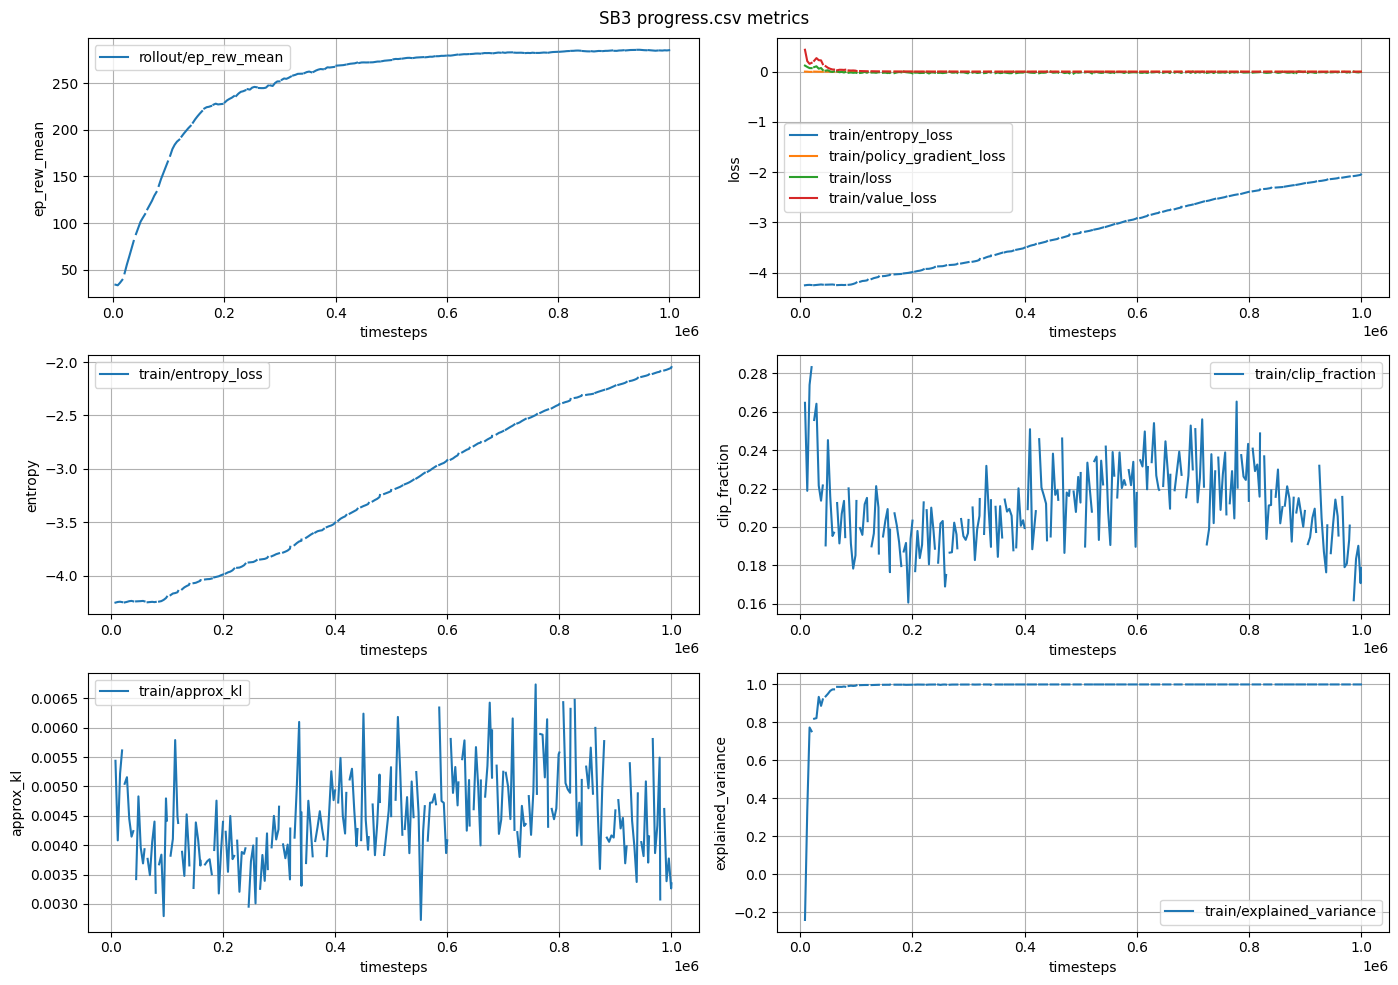

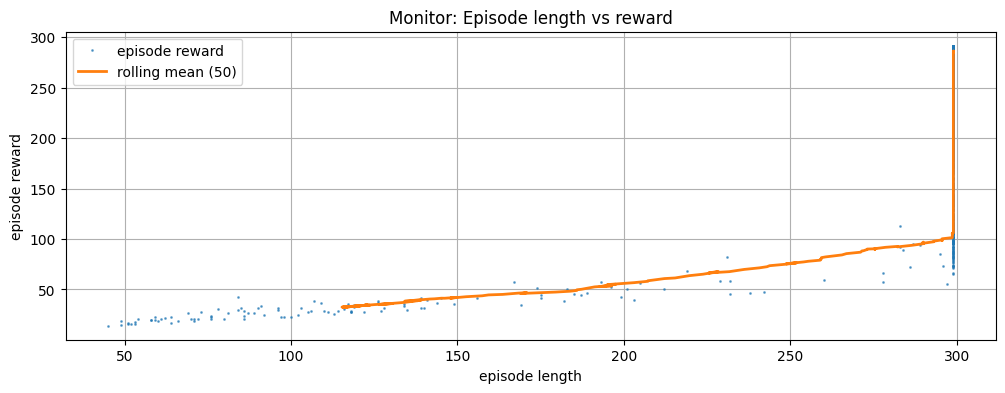

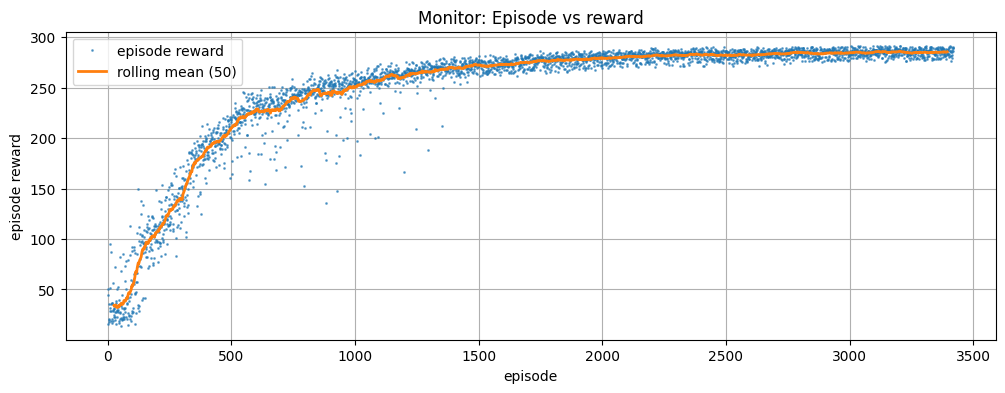

In [ ]:
# [Cell 7] 학습 곡선 시각화: 보상/길이(모니터), 손실/엔트로피/클립/KL(진행 로그)
# - SB3 progress.csv와 Monitor CSV를 함께 시각화

from pathlib import Path
import io

def _find_progress_csv(root: Path) -> Path:
    c = list(root.glob("**/progress.csv"))
    return c[0] if c else None

def _safe_plot(ax, x, y, label, xlabel=None, ylabel=None):
    if len(x) and len(y):
        ax.plot(x, y, label=label)
        if xlabel: ax.set_xlabel(xlabel)
        if ylabel: ax.set_ylabel(ylabel)
        ax.grid(True); ax.legend()

# 1) progress.csv (학습 중 수집된 집계 통계)
prog_csv = _find_progress_csv(ROOT)
if prog_csv is None:
    print("progress.csv를 찾지 못했습니다:", ROOT)
else:
    dfp = pd.read_csv(prog_csv)
    # 공통 x축
    x = dfp.get("time/total_timesteps", pd.Series(range(len(dfp))))
    cols_reward = [c for c in dfp.columns if "ep_rew_mean" in c]  # rollout/ep_rew_mean 등
    cols_loss = [c for c in dfp.columns if "value_loss" in c or "loss" in c]
    cols_entropy = [c for c in dfp.columns if "entropy" in c]
    cols_clip = [c for c in dfp.columns if "clip_fraction" in c]
    cols_kl = [c for c in dfp.columns if "approx_kl" in c]
    cols_ev = [c for c in dfp.columns if "explained_variance" in c]

    nrows = 3
    ncols = 2
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 10))
    axes = axes.ravel()

    # 보상
    if cols_reward:
        for c in cols_reward:
            _safe_plot(axes[0], x, dfp[c], c, "timesteps", "ep_rew_mean")
    else:
        axes[0].text(0.5, 0.5, "no ep_rew_mean", ha="center")

    # 손실
    if cols_loss:
        for c in cols_loss:
            _safe_plot(axes[1], x, dfp[c], c, "timesteps", "loss")
    else:
        axes[1].text(0.5, 0.5, "no loss column", ha="center")

    # 엔트로피
    if cols_entropy:
        for c in cols_entropy:
            _safe_plot(axes[2], x, dfp[c], c, "timesteps", "entropy")
    else:
        axes[2].text(0.5, 0.5, "no entropy column", ha="center")

    # clip fraction
    if cols_clip:
        for c in cols_clip:
            _safe_plot(axes[3], x, dfp[c], c, "timesteps", "clip_fraction")
    else:
        axes[3].text(0.5, 0.5, "no clip_fraction", ha="center")

    # approx KL
    if cols_kl:
        for c in cols_kl:
            _safe_plot(axes[4], x, dfp[c], c, "timesteps", "approx_kl")
    else:
        axes[4].text(0.5, 0.5, "no approx_kl", ha="center")

    # explained variance
    if cols_ev:
        for c in cols_ev:
            _safe_plot(axes[5], x, dfp[c], c, "timesteps", "explained_variance")
    else:
        axes[5].text(0.5, 0.5, "no explained_variance", ha="center")

    plt.suptitle("SB3 progress.csv metrics")
    plt.tight_layout()
    plt.show()

# 2) Monitor CSV(에피소드별 보상/길이)
mon_files = sorted(ROOT.glob("vecmonitor.csv"))
if not mon_files:
    print("Monitor 파일을 찾지 못했습니다:", ROOT)
else:
    dfs = []
    for f in mon_files:
        # 가장 간단한 방법: 주석('#') 라인을 무시하고 바로 읽기
        try:
            df = pd.read_csv(f, comment="#")
        except Exception:
            # 인코딩/형식 이슈가 있을 때만 수동 파싱
            with open(f, "r", encoding="utf-8", errors="ignore") as fh:
                lines = [ln for ln in fh if not ln.startswith("#")]
            df = pd.read_csv(io.StringIO("".join(lines)))
        dfs.append(df)

    if dfs:
        dfm = pd.concat(dfs, ignore_index=True)

        # 길이-보상 관계
        fig, ax = plt.subplots(figsize=(12,4))
        ax.plot(dfm["l"], dfm["r"], ".", markersize=2, alpha=0.6, label="episode reward")
        if len(dfm) > 20:
            ax.plot(dfm["l"].rolling(50).mean(), dfm["r"].rolling(50).mean(),
                    linewidth=2, label="rolling mean (50)")
        ax.set_xlabel("episode length")
        ax.set_ylabel("episode reward")
        ax.grid(True); ax.legend()
        ax.set_title("Monitor: Episode length vs reward")
        plt.show()

        # 에피소드 번호 대비 보상(옵션)
        dfm["episode"] = range(1, len(dfm) + 1)
        fig, ax = plt.subplots(figsize=(12,4))
        ax.plot(dfm["episode"], dfm["r"], ".", markersize=2, alpha=0.6, label="episode reward")
        if len(dfm) > 20:
            ax.plot(dfm["episode"].rolling(50).mean(), dfm["r"].rolling(50).mean(),
                    linewidth=2, label="rolling mean (50)")
        ax.set_xlabel("episode")
        ax.set_ylabel("episode reward")
        ax.grid(True); ax.legend()
        ax.set_title("Monitor: Episode vs reward")
        plt.show()


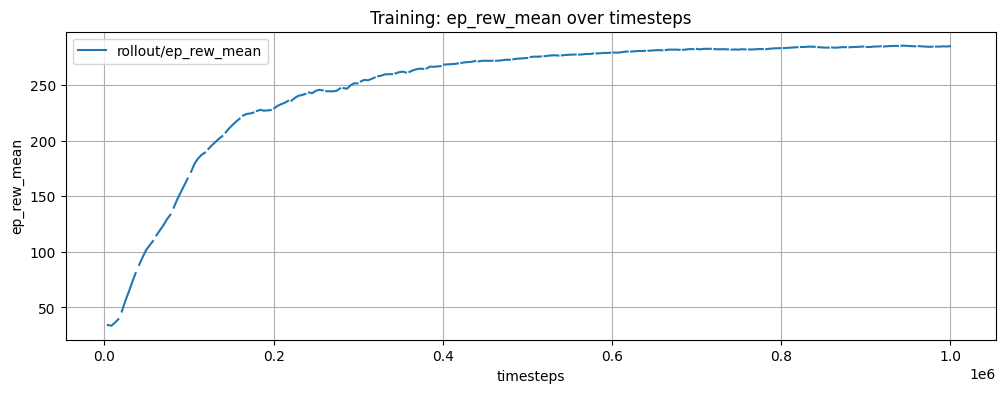

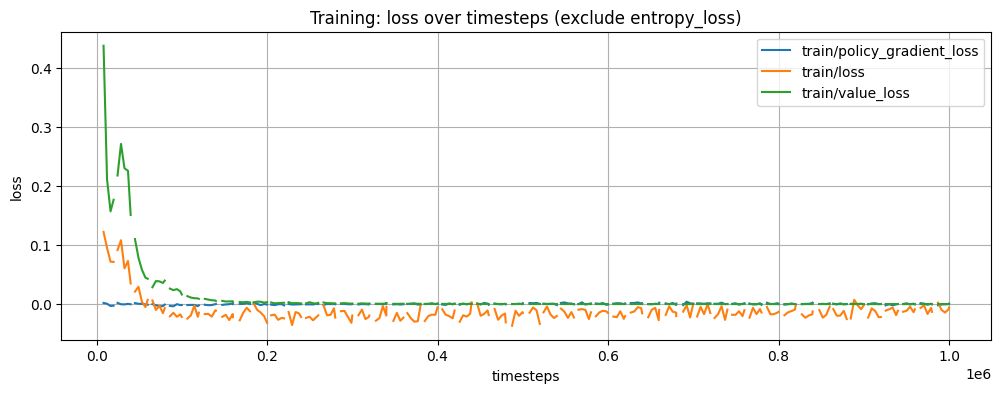

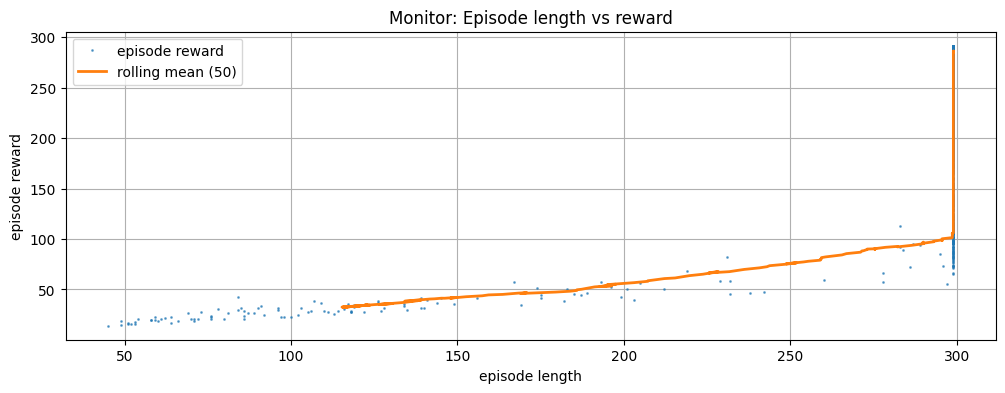

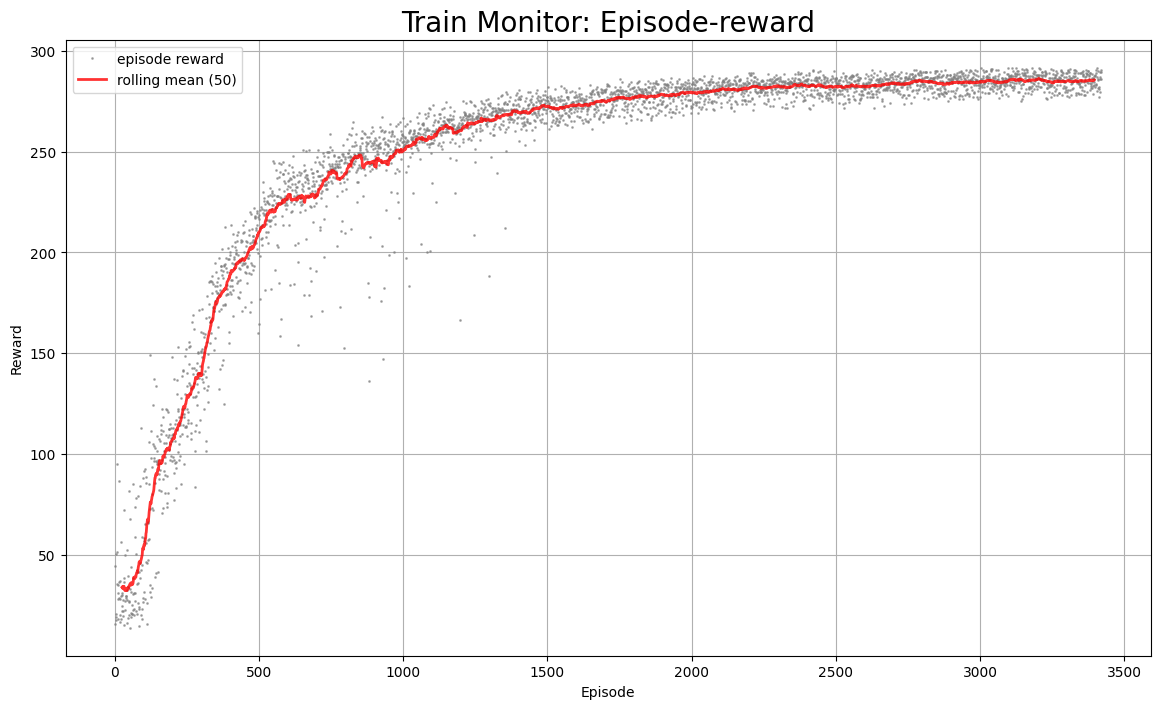

In [20]:
# [Cell 7] 학습 곡선 시각화: 보상/길이(모니터), 손실(진행 로그)
# - SB3 progress.csv: (1) timesteps-ep_rew_mean, (2) timesteps-loss(entropy_loss 제외)
# - Monitor CSV: 에피소드 보상

from pathlib import Path
import io

def _find_progress_csv(root: Path) -> Path:
    c = list(root.glob("**/progress.csv"))
    return c[0] if c else None

# 1) progress.csv (학습 중 수집된 집계 통계)
prog_csv = _find_progress_csv(ROOT)
if prog_csv is None:
    print("progress.csv를 찾지 못했습니다:", ROOT)
else:
    dfp = pd.read_csv(prog_csv)
    # 공통 x축
    x = dfp.get("time/total_timesteps", pd.Series(range(len(dfp))))

    # (1) timesteps - ep_rew_mean
    cols_reward = [c for c in dfp.columns if "ep_rew_mean" in c]  # rollout/ep_rew_mean 등
    if cols_reward:
        plt.figure(figsize=(12, 4))
        for c in cols_reward:
            plt.plot(x, dfp[c], label=c)
        plt.xlabel("timesteps")
        plt.ylabel("ep_rew_mean")
        plt.title("Training: ep_rew_mean over timesteps")
        plt.grid(True); plt.legend()
        plt.show()
    else:
        print("ep_rew_mean 열을 찾지 못했습니다:", list(dfp.columns)[:10], "...")

    # (2) timesteps - loss (entropy_loss 제외하고 3개만: value_loss, policy_gradient_loss, loss)
    desired_loss_keys = {"train/value_loss", "train/policy_gradient_loss", "train/loss"}
    # 존재하는 것만 선택
    loss_cols = [c for c in dfp.columns if c in desired_loss_keys]

    # 만약 컬럼명이 버전에 따라 조금 다른 경우를 대비해 보조 필터 적용
    if not loss_cols:
        loss_cols = [c for c in dfp.columns
                     if "loss" in c and "entropy_loss" not in c]

    if loss_cols:
        plt.figure(figsize=(12, 4))
        for c in loss_cols:
            plt.plot(x, dfp[c], label=c)
        plt.xlabel("timesteps")
        plt.ylabel("loss")
        plt.title("Training: loss over timesteps (exclude entropy_loss)")
        plt.grid(True); plt.legend()
        plt.show()
    else:
        print("표시할 loss 열이 없습니다(entropy_loss 제외).")

# 2) Monitor CSV(에피소드별 보상/길이)
mon_files = sorted(ROOT.glob("vecmonitor.csv"))
if not mon_files:
    print("Monitor 파일을 찾지 못했습니다:", ROOT)
else:
    dfs = []
    for f in mon_files:
        # 가장 간단한 방법: 주석('#') 라인을 무시하고 바로 읽기
        try:
            df = pd.read_csv(f, comment="#")
        except Exception:
            # 인코딩/형식 이슈가 있을 때만 수동 파싱
            with open(f, "r", encoding="utf-8", errors="ignore") as fh:
                lines = [ln for ln in fh if not ln.startswith("#")]
            df = pd.read_csv(io.StringIO("".join(lines)))
        dfs.append(df)

    if dfs:
        dfm = pd.concat(dfs, ignore_index=True)

        # 길이-보상 관계
        fig, ax = plt.subplots(figsize=(12,4))
        ax.plot(dfm["l"], dfm["r"], ".", markersize=2, alpha=0.6, label="episode reward")
        if len(dfm) > 20:
            ax.plot(dfm["l"].rolling(50).mean(), dfm["r"].rolling(50).mean(),
                    linewidth=2, label="rolling mean (50)")
        ax.set_xlabel("episode length")
        ax.set_ylabel("episode reward")
        ax.grid(True); ax.legend()
        ax.set_title("Monitor: Episode length vs reward")
        plt.show()

        # 에피소드 번호 대비 보상(옵션)
        dfm["episode"] = range(1, len(dfm) + 1)
        fig, ax = plt.subplots(figsize=(14,8))
        ax.plot(dfm["episode"], dfm["r"], ".", markersize=2, alpha=0.6, label="episode reward", color="gray")
        if len(dfm) > 20:
            ax.plot(dfm["episode"].rolling(50).mean(), dfm["r"].rolling(50).mean(),
                    linewidth=2, label="rolling mean (50)", color="red", alpha=0.8)
        ax.set_xlabel("Episode")
        ax.set_ylabel("Reward")
        ax.grid(True); ax.legend()
        ax.set_title("Train Monitor: Episode-reward", fontsize=20)
        plt.show()


In [ ]:
# [Cell 8] 최고 모델 로드 & 평가
# - best_model이 없으면 final_model로 대체 평가

# VecNormalize 통계 로드 헬퍼
def load_vecnormalize(path: Path, venv):
    try:
        vn = VecNormalize.load(str(path), venv)
        vn.training = False
        vn.norm_reward = False
        return vn
    except Exception:
        return venv

best_model_zip = MODEL_DIR / "best" / "best_model.zip"
eval_model_path = best_model_zip if best_model_zip.exists() else MODEL_DIR / "final_model.zip"

# 평가용 환경 재구성(통계 반영)
_base_eval_env = build_vec_env(1, SEED + 10_001, EVAL_DIR / "post")
_base_eval_env.training = False
_base_eval_env.norm_reward = False

vecstat_path = MODEL_DIR / "vecnormalize.pkl"
eval_env_post = load_vecnormalize(vecstat_path, _base_eval_env)

# 모델 로드
m = PPO.load(str(eval_model_path), env=eval_env_post, print_system_info=True)

mean_rew, std_rew = evaluate_policy(m, eval_env_post, n_eval_episodes=10, deterministic=True, render=False)
print(f"평가 결과: mean={mean_rew:.3f}, std={std_rew:.3f}")

# 샘플 1에피소드 궤적 보상 추이 플롯
obs = eval_env_post.reset()
rews = []
for t in range(5000):  # 충분히 길게
    action, _ = m.predict(obs, deterministic=True)
    obs, reward, done, info = eval_env_post.step(action)
    rews.append(reward)
    if done:
        break

plt.figure(figsize=(10,3))
plt.plot(rews)
plt.title("Sample evaluation episode rewards over steps")
plt.xlabel("step")
plt.ylabel("reward")
plt.grid(True)
plt.show()


In [ ]:
# # [Cell 9] 학습 재개(옵션)
# # - 같은 설정으로 이어서 학습하고 싶을 때 사용
# MORE_STEPS = 100_000
# print(f"추가 학습: {MORE_STEPS:,} steps")
# model.learn(total_timesteps=MORE_STEPS, callback=callbacks, reset_num_timesteps=False, progress_bar=True)
# model.save(str(MODEL_DIR / "final_model_continued"))
# train_env.save(str(MODEL_DIR / "vecnormalize.pkl"))
# print("추가 학습 완료")


In [17]:
# [Cell 10] 참고: 하이퍼파라미터 기록(JSON 저장) - 안정화 튜닝 반영본
hparams = {
    "algo": "PPO",
    "env_id": ENV_ID,
    "n_envs": N_ENVS,
    "stack_frames": STACK_FRAMES,
    "seed": SEED,
    "use_domain_randomization": USE_DOMAIN_RANDOM,
    "action_l2_lambda": ACTION_L2_LAMBDA,
    "hyperparams": {
        "n_steps": 4096,
        "batch_size": 128,
        "n_epochs": 5,
        "gamma": 0.995,
        "gae_lambda": 0.95,
        "clip_range": 0.1,
        "clip_range_vf": 0.2,
        "target_kl": 0.02,
        "ent_coef": 0.005,
        "vf_coef": 0.5,
        "max_grad_norm": 1.0,
        "learning_rate": "linear(2e-4 -> 5e-5)",
        "policy_net_arch": [256, 256],
        "value_net_arch": [256, 256],
        "activation_fn": "Tanh",
        "ortho_init": False
    },
    "logging": {
        "tensorboard_log": str(TB_DIR),
        "eval_freq": 20000,
        "checkpoint_save_freq": 50000
    }
}

with open(ROOT / "hparams.json", "w") as f:
    json.dump(hparams, f, indent=2, ensure_ascii=False)

print("하이퍼파라미터 저장:", ROOT / "hparams.json")


하이퍼파라미터 저장: logs/ppo_jsbsim/20250810_163322/hparams.json
